<a href="https://colab.research.google.com/github/nightfox133/Java-projects/blob/main/FEMMES_AI_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Below are the packages required for this project. You do not need to modify the code below.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

We will attempt to connect to GPU to speed up training. For this to work, click connect in the top right, select "Change runtime type," then select GPU. If its prints "cuda" you're on GPU!

If not, don't worry, as this model will still train fine on CPU since it's relatively simple. This is mostly to practice moving models to GPU for future work, as when you need to run larger, more complex neural networks later, this will be essential.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Below is code to load the data. Fill in code where indicated and feel free to search things up to figure this out!

In [144]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle='FILL IN HERE') #TODO
test_loader = DataLoader(test_data, batch_size=64) #TODO

Display a few sample images in the dataset. No need to modify the code below.

In [ ]:
images, labels = next(iter(train_loader))  # get one batch

plt.figure(figsize=(8, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(labels[i].item())
    plt.axis("off")

plt.show()

Below is code for the CNN model. Complete the scaffold. Every instruction corresponds to one line of code you should add.

In [127]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # in_channels=1 for grayscale MNIST, out_channels=16
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 10)  # 64 channels, 7x7 spatial dimensions after two max pools on 28x28 input
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

This is code to create the model. Every time you rerun training, you must first rerun this cell, or you won't reset the model properly.

In [153]:
model = CNN().to(device)  # TODO: move model to GPU if available

Training. Fill in code where it says TODO.

In [156]:
# Setup
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
# -----------------------------
for epoch in range(3): #can adjust num of epochs later
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.1459
Epoch 2, Loss: 0.0204
Epoch 3, Loss: 0.0214


Evaluation

In [157]:
correct = total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 98.78%


Display sample images with prediction. No need to modify code below.

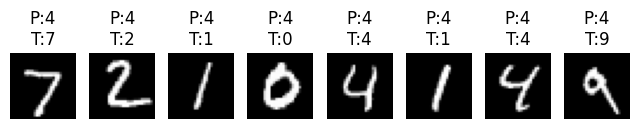

In [155]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

images = images.cpu()   # move back to CPU for plotting
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(8, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"P:{preds[i].item()}\nT:{labels[i].item()}")
    plt.axis("off")

plt.show()